In [1]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import make_classification 


In [2]:
X,y = make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.832704,-1.544445,-2.215207,-1.044203,-2.435464,1
1,1.404191,0.443493,0.297402,-1.872664,-0.713134,1
2,0.400084,-1.595909,-1.266155,-1.985749,-0.808434,1
3,0.088072,-3.127328,-2.626326,-2.059442,-1.546607,1
4,0.436918,-1.137087,-0.466077,3.111119,0.673386,0


In [8]:
# func for row sampling

def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [77]:
import random
# func for feature sampling
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df



In [10]:
# Function for combined sampling
def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [42]:
df1 = sample_rows(df,0.1)

In [43]:
df2 = sample_rows(df,0.1)

In [44]:
df3 = sample_rows(df,0.1)

In [45]:
df1.shape == df2.shape == df3.shape

True

In [46]:
from sklearn.tree import DecisionTreeClassifier 
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()


In [47]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:, -1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:, -1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:, -1])


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5, 0.75, 'x[4] <= 0.443\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

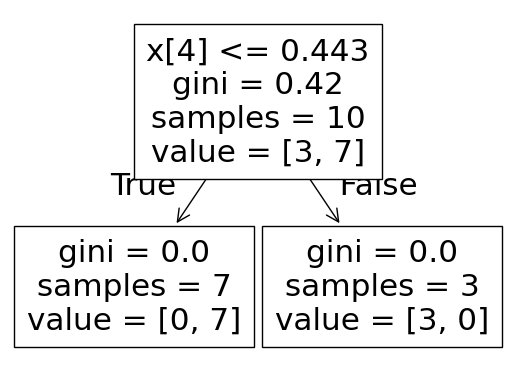

In [48]:
from sklearn.tree import plot_tree 

plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.4\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[4] <= -0.576\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]')]

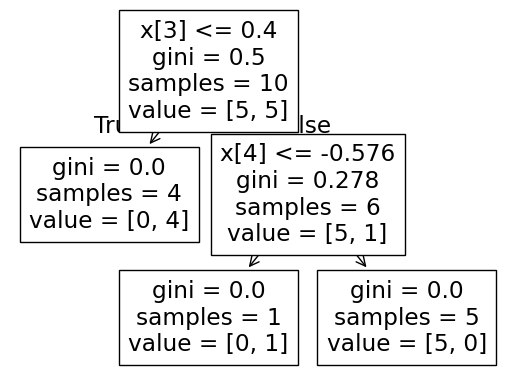

In [49]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[4] <= 0.074\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.4, 0.5, 'x[1] <= -3.112\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

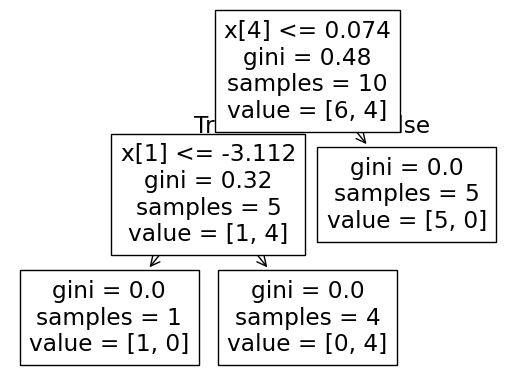

In [50]:
plot_tree(clf3)

In [55]:
df.sample(3)

,col1,col2,col3,col4,col5,target
78,-0.250659,-1.092089,0.460980,1.427839,0.400098,0
62,1.345482,0.392028,-0.063045,0.614506,-0.949326,1
75,1.142703,-1.280762,-1.182104,-2.568322,-1.410346,1


In [59]:
clf1.predict(np.array([	-0.250659,-1.092089,0.460980,1.427839,0.400098]).reshape(1,5))

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [57]:
clf2.predict(np.array([	-0.250659,-1.092089,0.460980,1.427839,0.400098]).reshape(1,5))


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [58]:
clf3.predict(np.array([	-0.250659,-1.092089,0.460980,1.427839,0.400098]).reshape(1,5))


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [102]:
# Using sample Features 

df1 = sample_features(df,0.8)
df2 = sample_features(df,0.8)
df3 = sample_features(df,0.8)


/tmp/ipykernel_4725/3707019809.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4725/3707019809.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4725/3707019809.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [103]:
df1.shape == df2.shape == df3.shape

True

In [104]:
df3

,col2,col1,col3,col5,target
0,-1.544445,0.832704,-2.215207,-2.435464,1
1,0.443493,1.404191,0.297402,-0.713134,1
2,-1.595909,0.400084,-1.266155,-0.808434,1
3,-3.127328,0.088072,-2.626326,-1.546607,1
4,-1.137087,0.436918,-0.466077,0.673386,0
...,...,...,...,...,...
95,0.964739,2.724416,2.636997,2.228706,0
96,-1.348820,1.390250,-0.205654,1.535142,0
97,0.513927,2.585390,1.718415,2.624667,0
98,-1.820497,-0.204449,-0.131200,1.097369,0


In [105]:
from sklearn.tree import DecisionTreeClassifier 
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()


In [106]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:, -1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:, -1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:, -1])


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [107]:
from sklearn.tree import plot_tree

[Text(0.3333333333333333, 0.9285714285714286, 'x[1] <= 0.079\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[3] <= 1.08\ngini = 0.162\nsamples = 45\nvalue = [4, 41]'),
 Text(0.25, 0.8571428571428572, 'True  '),
 Text(0.08333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 40\nvalue = [0, 40]'),
 Text(0.25, 0.6428571428571429, 'x[1] <= -1.085\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.5, 0.7857142857142857, 'x[3] <= -1.205\ngini = 0.274\nsamples = 55\nvalue = [46, 9]'),
 Text(0.41666666666666663, 0.8571428571428572, '  False'),
 Text(0.4166666666666667, 0.6428571428571429, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.5833333333333334, 0.6428571428571429, 'x[0] <= -1.736\ngini = 0.177\nsamples = 51\nvalue = [46, 5]'),
 Text(0.5, 0.5, 'gini = 0.0\nsamples = 2\nvalue 

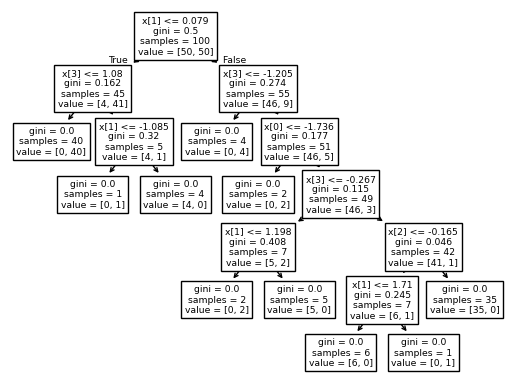

In [108]:
plot_tree(clf1)

[Text(0.3333333333333333, 0.9285714285714286, 'x[0] <= 0.079\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[1] <= 1.08\ngini = 0.162\nsamples = 45\nvalue = [4, 41]'),
 Text(0.25, 0.8571428571428572, 'True  '),
 Text(0.08333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 40\nvalue = [0, 40]'),
 Text(0.25, 0.6428571428571429, 'x[0] <= -1.085\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.5, 0.7857142857142857, 'x[1] <= -1.205\ngini = 0.274\nsamples = 55\nvalue = [46, 9]'),
 Text(0.41666666666666663, 0.8571428571428572, '  False'),
 Text(0.4166666666666667, 0.6428571428571429, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.5833333333333334, 0.6428571428571429, 'x[3] <= -1.736\ngini = 0.177\nsamples = 51\nvalue = [46, 5]'),
 Text(0.5, 0.5, 'gini = 0.0\nsamples = 2\nvalue 

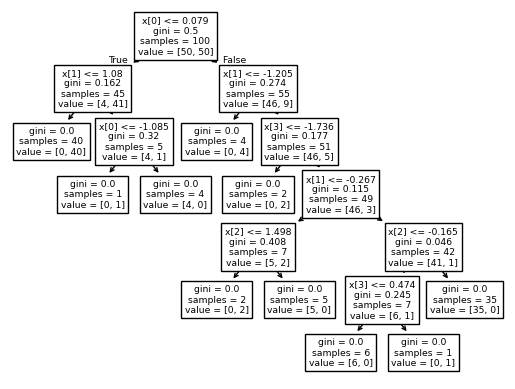

In [109]:
plot_tree(clf2)

[Text(0.4411764705882353, 0.9375, 'x[3] <= 0.079\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.23529411764705882, 0.8125, 'x[0] <= -3.266\ngini = 0.162\nsamples = 45\nvalue = [4, 41]'),
 Text(0.3382352941176471, 0.875, 'True  '),
 Text(0.11764705882352941, 0.6875, 'x[2] <= -1.347\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.058823529411764705, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.17647058823529413, 0.5625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.35294117647058826, 0.6875, 'x[2] <= 0.987\ngini = 0.048\nsamples = 41\nvalue = [1, 40]'),
 Text(0.29411764705882354, 0.5625, 'gini = 0.0\nsamples = 40\nvalue = [0, 40]'),
 Text(0.4117647058823529, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6470588235294118, 0.8125, 'x[0] <= -3.12\ngini = 0.274\nsamples = 55\nvalue = [46, 9]'),
 Text(0.5441176470588236, 0.875, '  False'),
 Text(0.5882352941176471, 0.6875, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.7058823529411765, 0

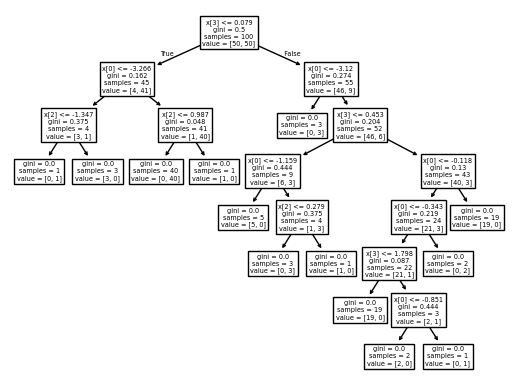

In [110]:
plot_tree(clf3)

In [118]:
clf1.predict(np.array([-0.250659,-1.092089,0.460980,0.443493]).reshape(1,4))


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [119]:
clf2.predict(np.array([-0.250659,-1.092089,0.460980,0.443493]).reshape(1,4))


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [120]:
clf3.predict(np.array([-0.250659,-1.092089,0.460980,0.443493]).reshape(1,4))


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [116]:
df2

,col5,col4,col1,col3,target
0,-2.435464,-1.044203,0.832704,-2.215207,1
1,-0.713134,-1.872664,1.404191,0.297402,1
2,-0.808434,-1.985749,0.400084,-1.266155,1
3,-1.546607,-2.059442,0.088072,-2.626326,1
4,0.673386,3.111119,0.436918,-0.466077,0
...,...,...,...,...,...
95,2.228706,-0.878959,2.724416,2.636997,0
96,1.535142,2.108667,1.390250,-0.205654,0
97,2.624667,0.298110,2.585390,1.718415,0
98,1.097369,1.765787,-0.204449,-0.131200,0


In [115]:
df

,col1,col2,col3,col4,col5,target
0,0.832704,-1.544445,-2.215207,-1.044203,-2.435464,1
1,1.404191,0.443493,0.297402,-1.872664,-0.713134,1
2,0.400084,-1.595909,-1.266155,-1.985749,-0.808434,1
3,0.088072,-3.127328,-2.626326,-2.059442,-1.546607,1
4,0.436918,-1.137087,-0.466077,3.111119,0.673386,0
...,...,...,...,...,...,...
95,2.724416,0.964739,2.636997,-0.878959,2.228706,0
96,1.390250,-1.348820,-0.205654,2.108667,1.535142,0
97,2.585390,0.513927,1.718415,0.298110,2.624667,0
98,-0.204449,-1.820497,-0.131200,1.765787,1.097369,0
